IMPORTS

In [2]:
import shap
import joblib
import numpy as np
import matplotlib
import pandas as pd

In [3]:
LR_model = joblib.load("../models/lr_model.pkl")
X_test_A = joblib.load("../models/X_test_A.pkl")
X_test_LR = joblib.load("../models/X_test_LR.pkl")
X_train_LR = joblib.load("../models/X_train_LR.pkl")
xgb_A = joblib.load("../models/xgb_A.pkl")
y_test = joblib.load("../models/y_test.pkl")

c:\Users\Aryan\anaconda3\envs\credit_scorecard\lib\site-packages\xgboost\core.py:158: UserWarning: [18:57:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\data\../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


In [4]:
# For Logistic Regression
explainer_lr = shap.LinearExplainer(LR_model,X_train_LR)

# For XGBoost
explainer_xgb_A = shap.TreeExplainer(xgb_A)

In [5]:
shap_values_lr = explainer_lr.shap_values(X_test_LR)
shap_values_xgb_A = explainer_xgb_A.shap_values(X_test_A)

In [6]:
print(shap_values_lr.shape)
print(shap_values_xgb_A.shape)

(61501, 5)
(61501, 5)


Summary Plot

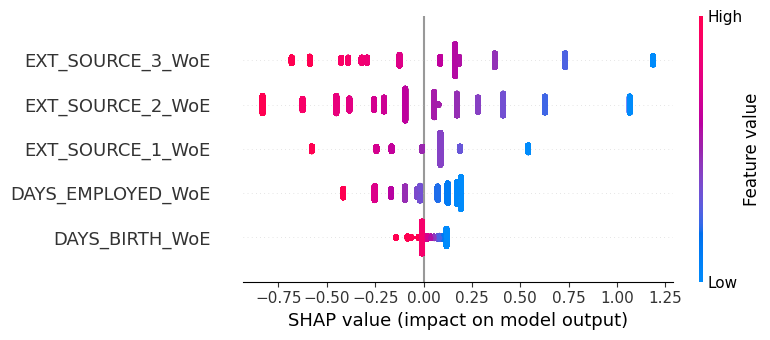

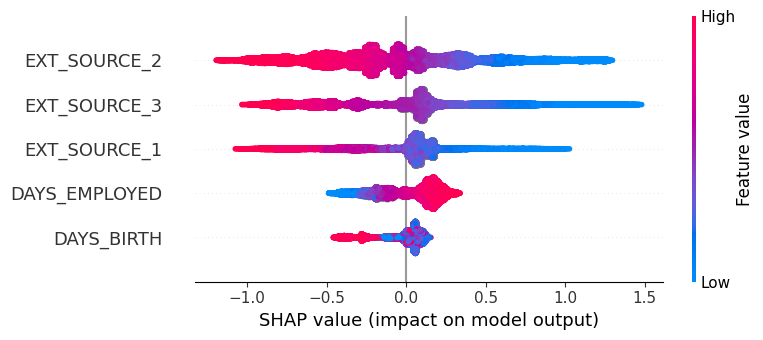

In [7]:
summary_plot_lr = shap.summary_plot(shap_values_lr,X_test_LR)
summary_plot_xgb_A = shap.summary_plot(shap_values_xgb_A,X_test_A)

In [8]:
mean_abs_shap = np.abs(shap_values_xgb_A).mean(axis=0)
percentages = (mean_abs_shap/mean_abs_shap.sum())*100
importance_df = pd.DataFrame({
    'Feature': X_test_A.columns,
    'mean_abs_SHAP': mean_abs_shap,
    'Percentage (%)': percentages 
})
importance_df

,Feature,mean_abs_SHAP,Percentage (%)
0,DAYS_BIRTH,0.106294,8.351517
1,DAYS_EMPLOYED,0.168609,13.247641
2,EXT_SOURCE_1,0.218229,17.146250
3,EXT_SOURCE_2,0.391751,30.779886
4,EXT_SOURCE_3,0.387866,30.474705


Top 3 riskiest applicants index calculation - xgb_A

In [9]:
proba_A = xgb_A.predict_proba(X_test_A)[:, 1]
top3_idx = np.argsort(proba_A)[-3:][::-1]

In [10]:
for i in range(len(top3_idx)):
    print(top3_idx[i])

26450
23631
42859


Waterfall Plot

26450


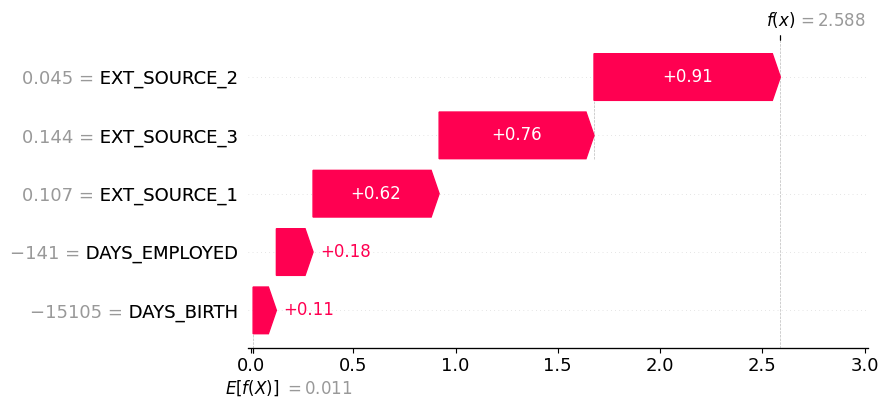

23631


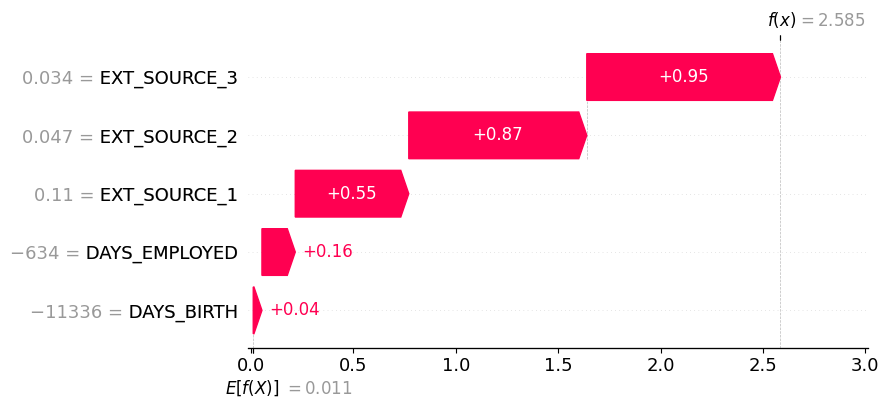

42859


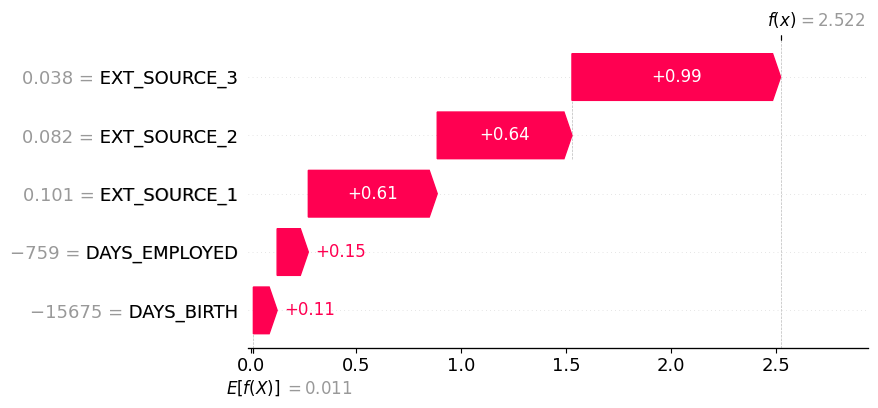

In [11]:
for idx in top3_idx:
    print(idx)
    shap_values = explainer_xgb_A(X_test_A.iloc[[idx]])
    shap.waterfall_plot(shap_values[0])

26450


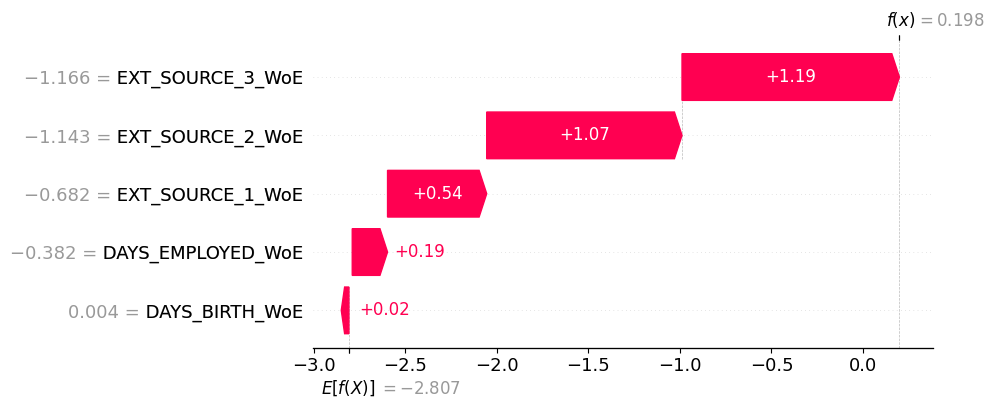

23631


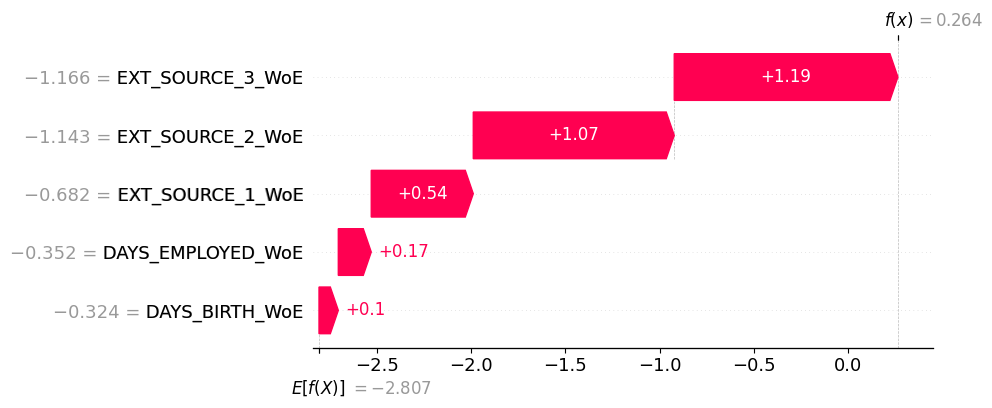

42859


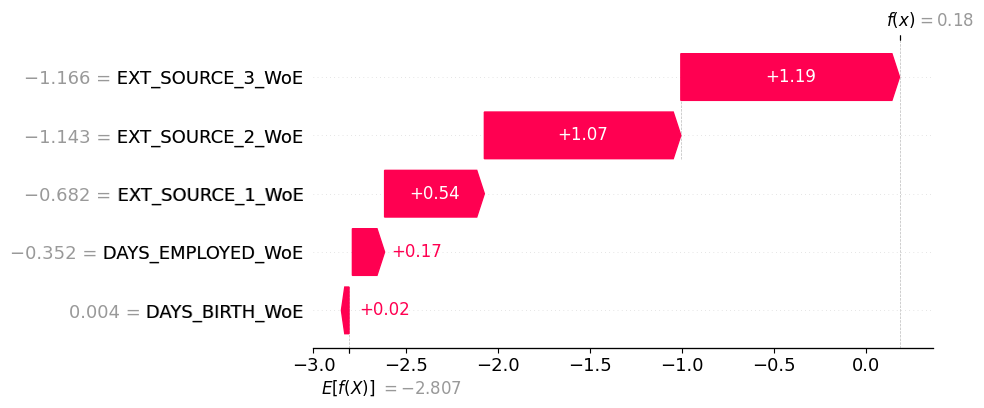

In [12]:
for idx in top3_idx:
    print(idx)
    shap_values = explainer_lr(X_test_LR.iloc[[idx]])
    shap.waterfall_plot(shap_values[0])

Dependence Plot

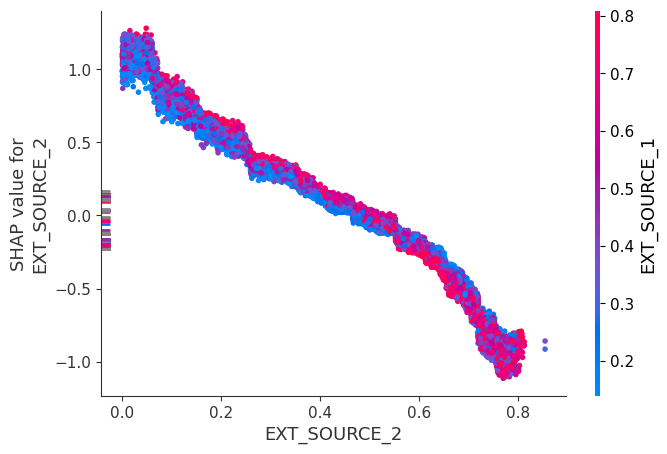

In [14]:
dependence_plot = shap.dependence_plot("EXT_SOURCE_2",shap_values_xgb_A,X_test_A)